<a href="https://colab.research.google.com/github/shaipshiverya/Credit_Card_Churn_Analysis/blob/main/Credit_Card_Churn_Analysis_finalv1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💳 Credit Card Customer Churn — Analysis & Insights
## A Banking & Finance Analytics Project

**Domain:** Banking & Finance  
**Dataset:** BankChurners — 10,127 customers, Kaggle  
**Source:** [Kaggle — Sakshi Goyal](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers)

---

### 🎯 Business Problem
Credit card churn is one of the biggest challenges banks face. When a customer cancels their credit card, the bank loses interchange fees, interest income, and future cross-sell revenue. This project analyzes customer behavior data to identify **why customers churn**, **which segments are highest risk**, and **how much revenue is at stake** — enabling retention teams to act before customers leave.

**End Users:** Bank retention teams & relationship managers

### 📋 Project Workflow
1. Data Loading & Understanding
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Rule-Based Risk Segmentation
5. Simple Prediction Model (Random Forest)
6. Business Impact — Revenue at Risk
7. Key Findings & Recommendations

---


##  Section 1: Setup — Install Libraries & Load Data

In [ ]:
print("All libraries ready")


All libraries ready


In [ ]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print("Libraries imported ")

Libraries imported 


In [ ]:
# Load the dataset
df = pd.read_csv('BankChurners.csv')

# Drop last 2 columns — these are Naive Bayes classifier outputs added by Kaggle, not real features
df = df.iloc[:, :-2]

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset shape: (10127, 21)

First few rows:


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


##  Section 2: Data Cleaning & Preprocessing

Steps:
- Check for missing values
- Understand data types
- Remove the customer ID column (not useful for modeling)

In [ ]:
# Check basic info
print("=== Dataset Info ===")
print(df.info())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null

In [ ]:
# Check for missing values
print("== Missing values per column: ==")
print("\nTotal missing values:", df.isnull().sum().sum())

== Missing values per column: ==

Total missing values: 0


In [ ]:
# Drop customer ID — not a feature
df = df.drop(columns=['CLIENTNUM'])

print("Cleaning complete!")
print("Final dataset shape:", df.shape)

Cleaning complete!
Final dataset shape: (10127, 20)


## Section 3: Exploratory Data Analysis (EDA)

We explore the data visually to understand patterns, distributions, and what separates churned customers from retained ones.

### 3.1 — Target Variable Distribution

Attrition Distribution:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64


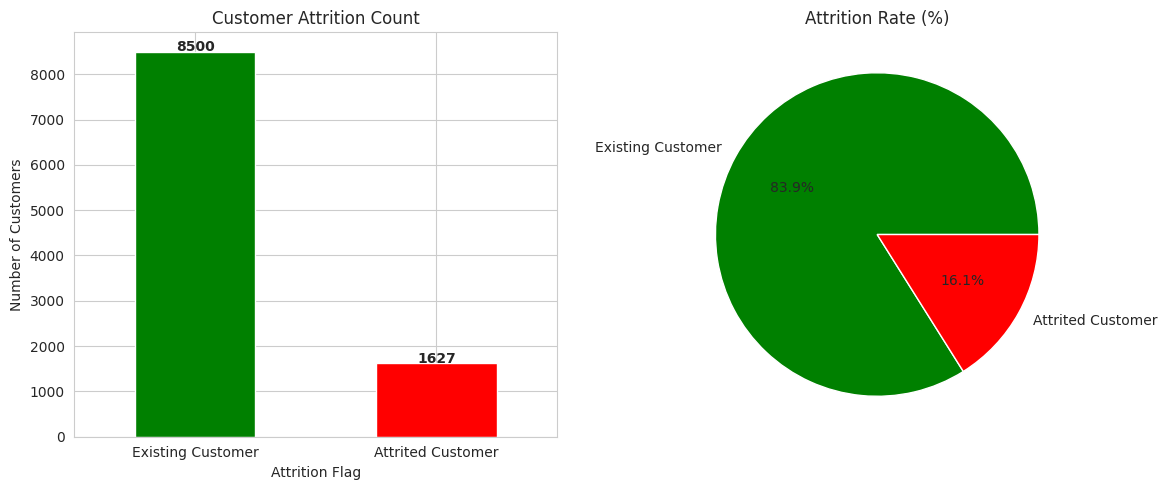

In [ ]:
# Attrition class distribution
print("Attrition Distribution:")
print(df['Attrition_Flag'].value_counts())


palette = {'Existing Customer': 'green', 'Attrited Customer': 'red'}
colors_list = ['green', 'red']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['Attrition_Flag'].value_counts()
counts.plot(kind='bar', color=colors_list, ax=axes[0])
axes[0].set_title('Customer Attrition Count')
axes[0].set_xlabel('Attrition Flag')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=0)

for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5,str(v),  ha='center', fontweight='bold')

counts.plot(kind='pie', autopct='%1.1f%%', colors= colors_list, ax=axes[1])
axes[1].set_title('Attrition Rate (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


** Insight:** The dataset is imbalanced — 84% of customers are retained vs 16% who churned.  
This means a model could get high accuracy just by guessing "retained" every time — so we'll need to look beyond plain accuracy when we evaluate the model later.


### 3.2 — Transaction Behavior: Churned vs Retained

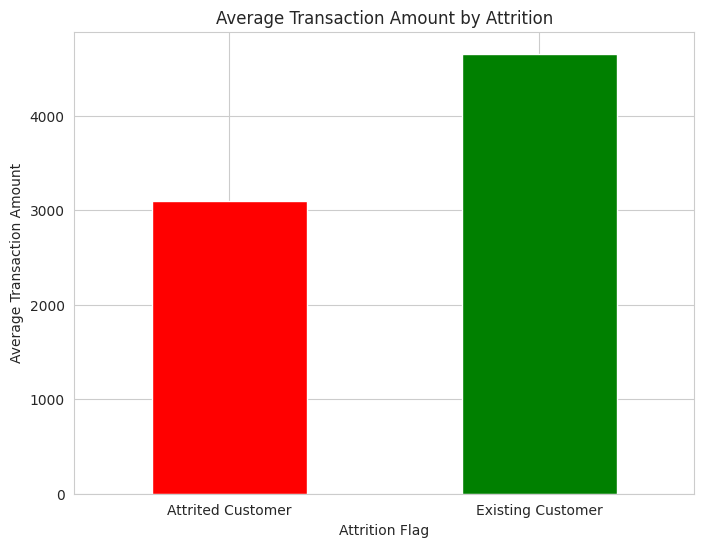

In [ ]:
trans_amt = df.groupby('Attrition_Flag')['Total_Trans_Amt'].mean()

plt.figure(figsize=(8,6))

trans_amt.plot(kind='bar', color = ['red','green'])

plt.title('Average Transaction Amount by Attrition')
plt.xlabel('Attrition Flag')
plt.ylabel('Average Transaction Amount')
plt.xticks(rotation=0)

plt.show()


** Insights:**
- **Transaction Amount:** Churned customers have significantly lower total transaction amounts
- **Transaction Count:** Churned customers make far fewer transactions — this is the strongest early warning signal
- The gap between the two groups is very clear — low engagement directly predicts churn

### 3.3 — Attrition by Card Category

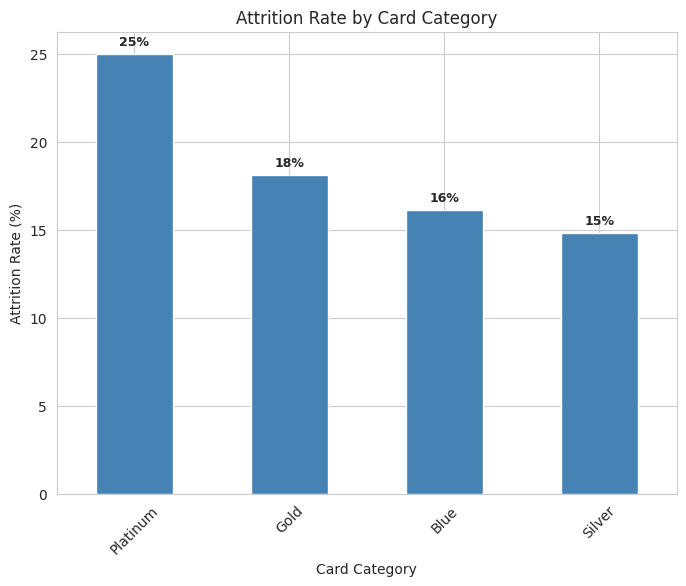

In [ ]:
card_churn = df.groupby('Card_Category')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(8,6))

ax = card_churn.plot(kind='bar', color='steelblue')

plt.title('Attrition Rate by Card Category')
plt.xlabel('Card Category')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
for i, v in enumerate(card_churn.values):
    ax.text(i, v + 0.5, f'{v:.0f}%', ha='center', fontweight='bold', fontsize=9)

plt.show()


** Insights:**
- Platinum cardholders have the highest churn rate despite being the most premium segment
- Blue cardholders (majority of customers) have the lowest churn rate
- Higher card tiers may reflect customers who were over-sold on premium products they don't use

### 3.4 — Months Inactive Distribution

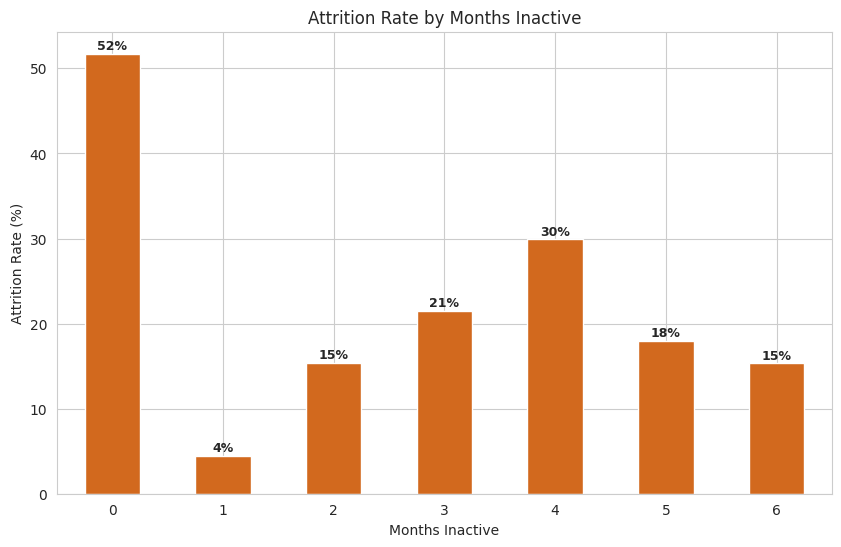

In [ ]:
inactive_churn = df.groupby('Months_Inactive_12_mon')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').mean() * 100
)

plt.figure(figsize=(10,6))

ax = inactive_churn.plot(kind='bar', color='chocolate')

plt.title('Attrition Rate by Months Inactive')
plt.xlabel('Months Inactive')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

for i, v in enumerate(inactive_churn.values):
    ax.text(i, v + 0.5, f'{v:.0f}%', ha='center', fontweight='bold', fontsize=9)

plt.show()


**Insight:** ​Immediate Re-engagement: Since 52% of attrition happens at the "0 month" mark, your team needs a strategy to re-engage users the very moment they stop showing activity.

​The "4-Month" Warning Sign: Since attrition spikes again at 4 months of inactivity, this is likely the "point of no return." Implementing a specific re-engagement campaign (like an email or offer) at the 3-month mark could help prevent that group from hitting the 30% churn threshold.

### 3.6 — Attrition by Number of Products Held

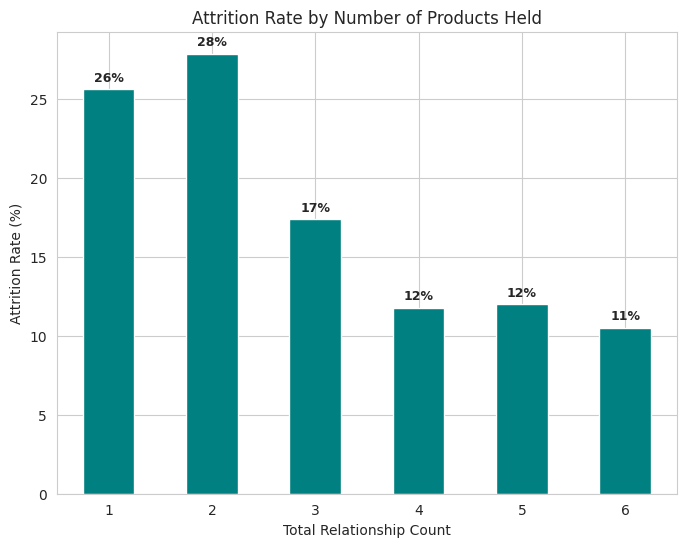

In [ ]:
rel_churn = df.groupby('Total_Relationship_Count')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').mean() * 100
)

plt.figure(figsize=(8,6))

ax = rel_churn.plot(kind='bar', color='teal')

plt.title('Attrition Rate by Number of Products Held')
plt.xlabel('Total Relationship Count')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

for i, v in enumerate(rel_churn.values):
    ax.text(i, v + 0.5, f'{v:.0f}%', ha='center', fontweight='bold', fontsize=9)

plt.show()


**Insight:** Customers with only 1-2 products show the highest churn rate — over 25%. Customers with 5-6 products churn at less than 7%. This confirms a clear pattern: **cross-selling more products increases retention.**


### 3.7 — Attrition by Customer Support Contacts

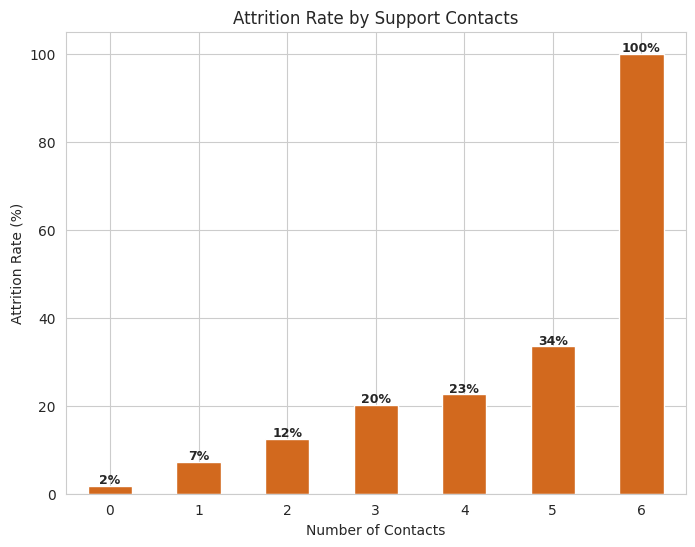

In [ ]:
contact_churn = df.groupby('Contacts_Count_12_mon')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').mean() * 100
)

plt.figure(figsize=(8,6))

ax = contact_churn.plot(kind='bar', color='chocolate')

plt.title('Attrition Rate by Support Contacts')
plt.xlabel('Number of Contacts')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

for i, v in enumerate(contact_churn.values):
    ax.text(i, v + 0.5, f'{v:.0f}%', ha='center', fontweight='bold', fontsize=9)

plt.show()


**Insight:** Customers with 4+ support contacts in a year churn at a much higher rate. Frequent contact often signals unresolved frustration — these customers should be flagged for proactive relationship manager outreach.


### 3.8 — Attrition by Income Category

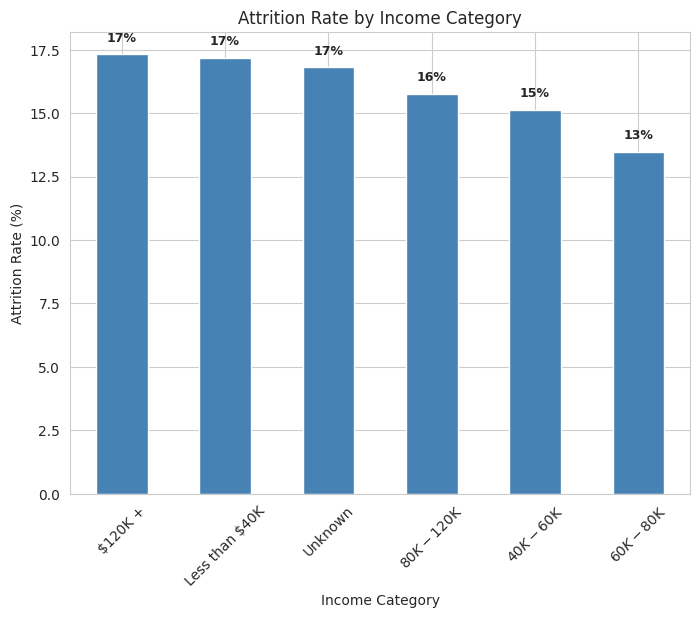

In [ ]:
income_churn = df.groupby('Income_Category')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(8,6))

ax =income_churn.plot(kind='bar', color='steelblue')

plt.title('Attrition Rate by Income Category')
plt.xlabel('Income Category')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)

for i, v in enumerate(income_churn.values):
    ax.text(i, v + 0.5, f'{v:.0f}%', ha='center', fontweight='bold', fontsize=9)

plt.show()


**Insight:** Churn rate is fairly consistent across income bands, suggesting income alone doesn't drive attrition — engagement and usage behavior matter far more than earning level.


### 3.9 — Customer Age Distribution by Attrition

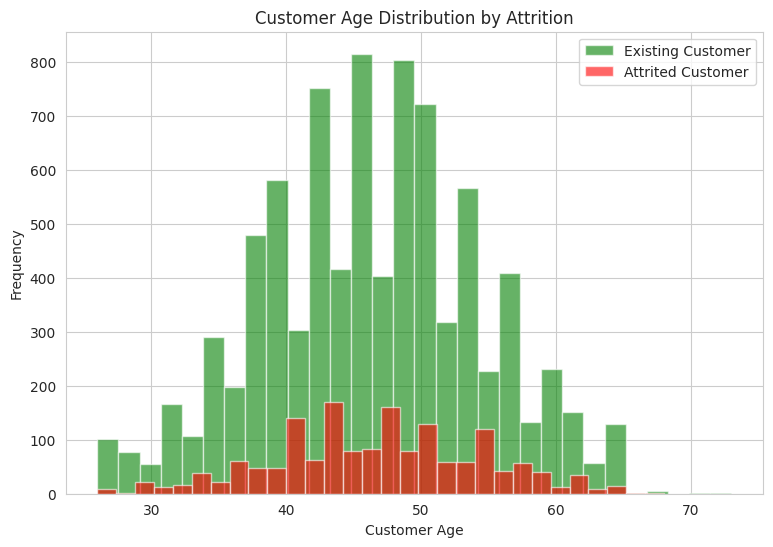

In [ ]:
plt.figure(figsize=(9,6))

x = df[df['Attrition_Flag']=='Existing Customer']['Customer_Age']
y = df[df['Attrition_Flag']=='Attrited Customer']['Customer_Age']

x.plot(kind='hist', alpha=0.6, color='green', label='Existing Customer', bins=30)
y.plot(kind='hist', alpha=0.6, color='red', label='Attrited Customer', bins=30)

plt.title('Customer Age Distribution by Attrition')
plt.xlabel('Customer Age')
plt.ylabel('Frequency')
plt.legend()

plt.show()


**Insight:** Age distributions largely overlap between churned and retained customers — age is not a strong standalone driver of attrition. Behavioral factors (transactions, inactivity) matter more than demographics.


### 3.10 — Credit Limit vs Utilization Ratio (Colored by Churn)

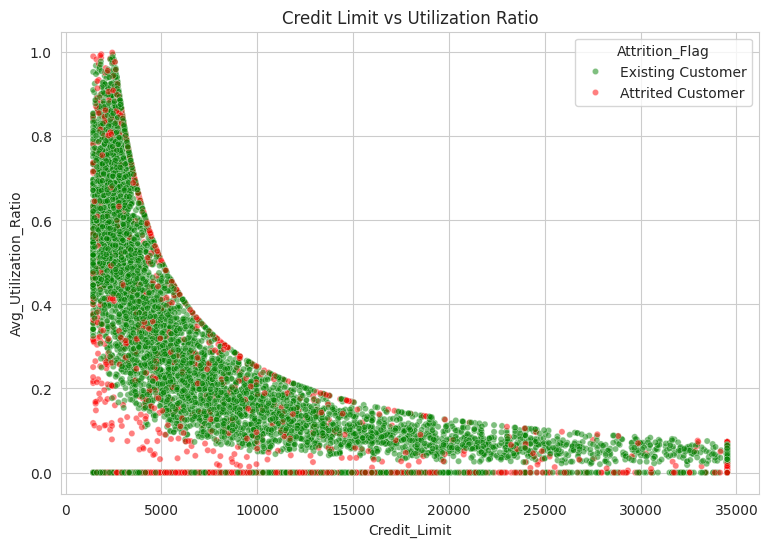

In [ ]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x='Credit_Limit',
    y='Avg_Utilization_Ratio',
    hue='Attrition_Flag',
    palette={'Existing Customer': 'green', 'Attrited Customer': 'red'},
    alpha=0.5,
    s=20
)

plt.title('Credit Limit vs Utilization Ratio')
plt.show()

**Insight:** Churned customers cluster heavily at **low utilization ratios** regardless of credit limit — they simply aren't using their card. Low utilization is a stronger churn signal than the credit limit itself.


### 3.11 — Attrition by Education Level

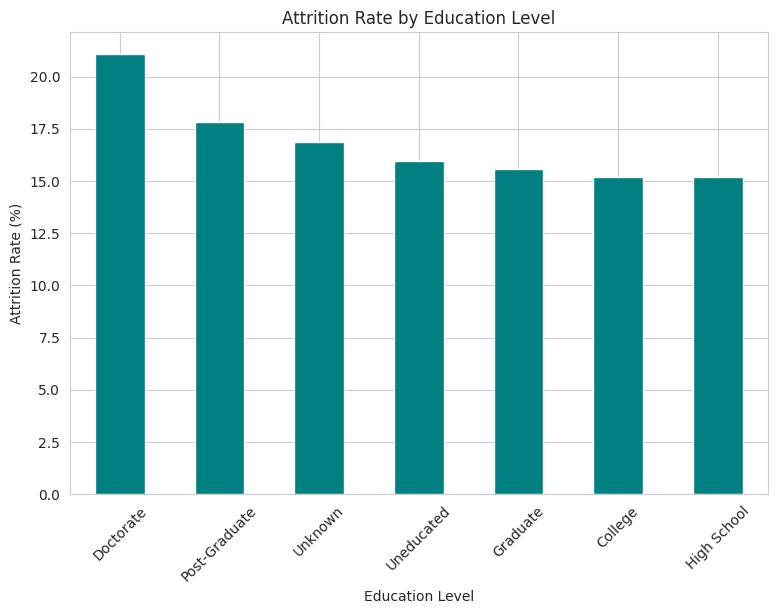

In [ ]:
edu_churn = df.groupby('Education_Level')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(9,6))

edu_churn.plot(kind='bar', color='teal')

plt.title('Attrition Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)

plt.show()


**Insight:** Churn rate is broadly similar across education levels — like income, education is not a meaningful standalone predictor of attrition.


### 3.12 — Transaction Count Distribution (Boxplot)

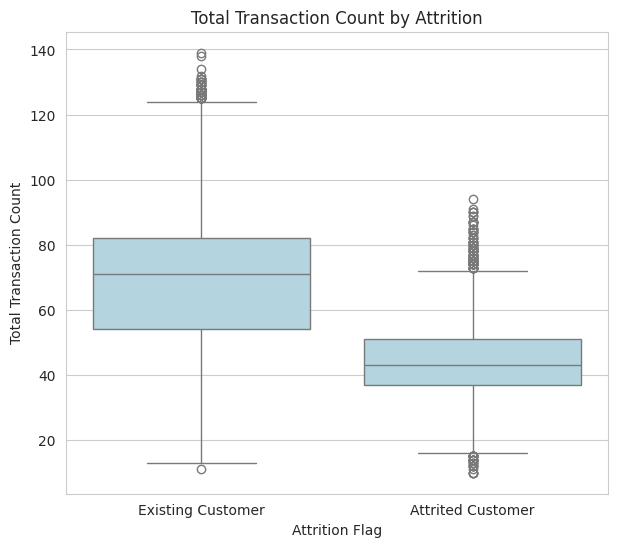

In [ ]:
plt.figure(figsize=(7,6))

sns.boxplot(x='Attrition_Flag', y='Total_Trans_Ct', data=df, color='lightblue')

plt.title('Total Transaction Count by Attrition')
plt.xlabel('Attrition Flag')
plt.ylabel('Total Transaction Count')

plt.show()


**Insight:** Retained customers show a much wider, higher transaction count range, while churned customers cluster tightly at low transaction counts. This is one of the clearest behavioral churn signals in the dataset.


## Section 4: Simple Prediction Model — Random Forest

The EDA above is useful on its own, but a simple machine learning model can combine many signals at once and rank customers by churn probability. We use a **Random Forest** — a beginner-friendly model made up of many decision trees, which tends to give solid results without much tuning.

### Strategy:
- **Train/Test split:** 80% training, 20% testing
- **Model:** Random Forest Classifier — easy to understand and gives us a feature importance ranking for free


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

df_model = df.copy()
df_model['is_churned'] = (df_model['Attrition_Flag'] == 'Attrited Customer').astype(int)
df_model = df_model.drop(columns=['Attrition_Flag'])

# Encode categorical columns so the model can use them
le = LabelEncoder()
for col in ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop(columns=['is_churned'])
y = df_model['is_churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')
print(f'Churn rate in train: {y_train.mean()*100:.1f}%')


Train size: 8,101 | Test size: 2,026
Churn rate in train: 16.1%


In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f'Random Forest trained')
print(f'Accuracy: {acc:.2%}')
print()
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))


Random Forest trained
Accuracy: 95.11%

              precision    recall  f1-score   support

    Retained       0.95      0.99      0.97      1701
     Churned       0.93      0.75      0.83       325

    accuracy                           0.95      2026
   macro avg       0.94      0.87      0.90      2026
weighted avg       0.95      0.95      0.95      2026



Why `class_weight='balanced'

Only ~16% of customers churn — without balancing, the model would just predict "retained" for everyone and still look accurate. This setting forces the model to pay more attention to the minority (churned) class.


### 5.1 — Feature Importance

Random Forests can rank which features were most useful for telling churned and retained customers apart.


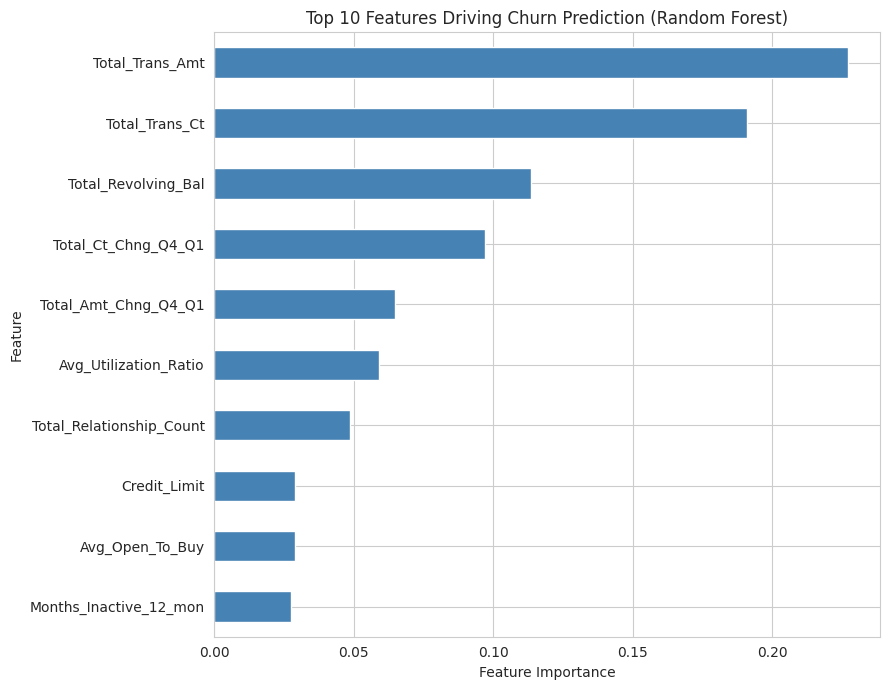

In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top_importances = importances.head(10)

plt.figure(figsize=(9, 7))
top_importances.sort_values().plot(kind='barh', color='steelblue')

plt.title('Top 10 Features Driving Churn Prediction (Random Forest)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


** Insight:** The most important features line up with what we already saw in the EDA — transaction count and amount, account inactivity, and the number of products held are the strongest drivers of churn. This confirms the patterns we found earlier and gives the retention team a clear, ranked list of what to watch for.


## Section 7: Key Findings & Recommendations

###  Key Findings
1. **Transaction count and amount** are the strongest behavioral churn signals — churned customers transact far less.
2. **Inactivity of 3+ months** sharply increases churn risk.
3. **Customers holding 1-2 products** churn at over 3x the rate of customers holding 5-6 products.
4. **4+ support contacts** in a year signals frustration and predicts higher churn.
5. **Low card utilization** (under 10%) is a stronger churn signal than credit limit itself.
6. **Combined risk factors compound** — inactive customers with few products churn far more than either factor alone.
7. **Demographics (age, income, education) are weak predictors** — behavior matters far more than who the customer is.

---

### Business Recommendations

**1. Cross-Sell Campaign for Low-Product Customers**  
Customers with 1-2 products are the highest-risk segment. A targeted campaign offering a 2nd or 3rd product (savings account, loan, insurance) could meaningfully reduce churn.

**2. Proactive Outreach for High-Contact Customers**  
Customers with 4+ support contacts should be automatically routed to a relationship manager for a retention call — frequent contact is an early warning sign, not just an operational cost.

**3. Reactivation Campaign for Inactive Customers**  
Customers inactive for 3+ months should receive targeted spend incentives (cashback, bonus rewards) before they fully disengage.

**4. Prioritize the Compound Risk Segment**  
Customers who are both inactive AND hold few products show the highest attrition of any group — this segment should be the #1 priority for retention budget allocation.

---

*Project by: Shaipshi | Tools: Python, pandas, scikit-learn |
